# Loan Approval Prediction Using Random Forest Classifier

## Machine Learning Assignment – Supervised Learning

---

## 1. Problem Description

Loan approval is a critical decision-making process in the banking and financial sector. Manually evaluating each application is time-consuming and prone to bias. This project applies a **Random Forest Classifier** to automatically predict whether a loan application should be approved (`Y`) or rejected (`N`) based on applicant details.

The dataset used is the **Loan Prediction Dataset** from Kaggle:
🔗 https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

**Target Variable:** `Loan_Status` (Y = Approved, N = Not Approved)


---

## 2. Dataset Description

The dataset contains **614 records** with **13 attributes** collected by a loan-providing company. Below is the attribute description:

| Feature | Type | Description |
|---|---|---|
| Loan_ID | Categorical | Unique loan identifier |
| Gender | Categorical | Male / Female |
| Married | Categorical | Applicant's marital status |
| Dependents | Numerical | Number of dependents |
| Education | Categorical | Graduate / Not Graduate |
| Self_Employed | Categorical | Self-employed status |
| ApplicantIncome | Numerical | Monthly income of applicant |
| CoapplicantIncome | Numerical | Monthly income of co-applicant |
| LoanAmount | Numerical | Loan amount (in thousands) |
| Loan_Amount_Term | Numerical | Term of loan in months |
| Credit_History | Binary | Credit history meets guidelines (1/0) |
| Property_Area | Categorical | Urban / Semi-urban / Rural |
| Loan_Status | Binary (Target) | Loan approved: Y / N |

**Dataset Size:** 614 rows × 13 columns  
**Class Distribution:** ~69% Approved (Y), ~31% Not Approved (N)


---

## 3. Background: Random Forest Algorithm

**Random Forest** is an ensemble learning method that constructs multiple decision trees during training and outputs the mode of the classes (classification) of the individual trees.

### Why Random Forest for this problem?
- Handles **missing values** and **outliers** well
- Works with both **numerical and categorical** features
- Resistant to **overfitting** (compared to single decision trees) via bagging
- Provides **feature importance** rankings
- Suitable for **imbalanced class distributions** with proper hyperparameter tuning

### Key Concepts
1. **Bootstrap Aggregation (Bagging):** Each tree is trained on a random sample (with replacement) of the training data
2. **Random Feature Selection:** At each node split, only a random subset of features is considered
3. **Majority Voting:** Final prediction is determined by voting across all trees


---

## 4. Import Libraries


In [1]:
# ── Standard libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ── Scikit-learn: preprocessing ──────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# ── Scikit-learn: model ───────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: evaluation metrics ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, f1_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


---

## 5. Load Data


In [3]:
# ── Load training and test datasets ──────────────────────────────────────────
# Dataset source: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
train_df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
test_df  = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

print(f"Training set shape : {train_df.shape}")
print(f"Test set shape     : {test_df.shape}")
train_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'train_u6lujuX_CVtuZ9i.csv'

### Download Dataset from Kaggle

First, we need to download the dataset from Kaggle. Make sure you have uploaded your `kaggle.json` API token as instructed above.

In [4]:
# This cell will set up the Kaggle API key for downloading datasets.
# Make sure you have uploaded 'kaggle.json' to '/root/.kaggle/'
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


In [5]:
# Download the dataset
# The dataset URL is: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
!kaggle datasets download -d altruistdelhite04/loan-prediction-problem-dataset

# Unzip the downloaded file
!unzip loan-prediction-problem-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
License(s): unknown
100% 12.6k/12.6k [00:00<00:00, 27.8MB/s]

Archive:  loan-prediction-problem-dataset.zip
  inflating: test_Y3wMUE5_7gLdaTN.csv  
  inflating: train_u6lujuX_CVtuZ9i.csv  


In [6]:
# ── Load training and test datasets ──────────────────────────────────────────
# Dataset source: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
train_df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
test_df  = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

print(f"Training set shape : {train_df.shape}")
print(f"Test set shape     : {test_df.shape}")
train_df.head()

Training set shape : (614, 13)
Test set shape     : (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
# ── Basic info ────────────────────────────────────────────────────────────────
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
# ── Statistical summary ───────────────────────────────────────────────────────
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


---

## 6. Exploratory Data Analysis (EDA)


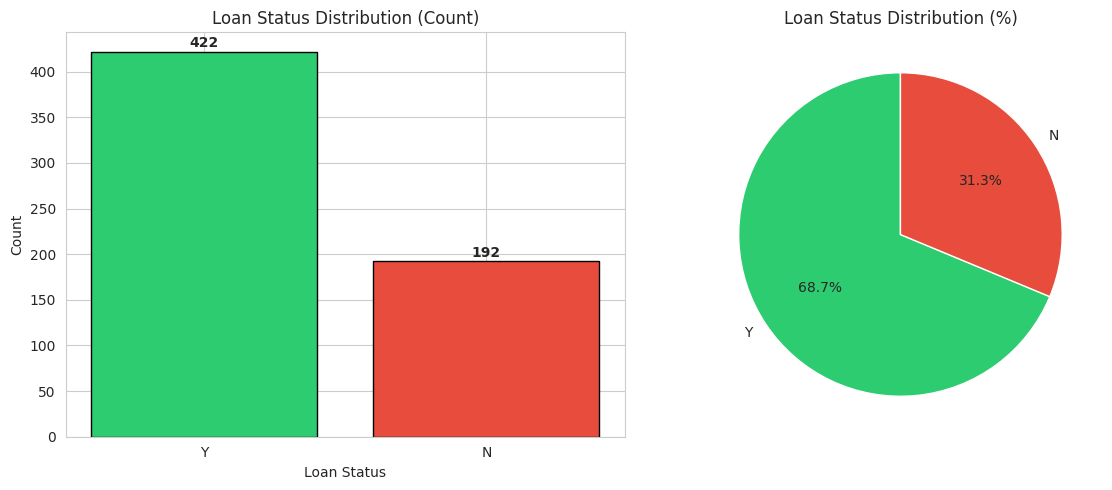

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [9]:
# ── Target variable distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

loan_counts = train_df['Loan_Status'].value_counts()
axes[0].bar(loan_counts.index, loan_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Loan Status Distribution (Count)')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(loan_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(loan_counts, labels=loan_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Loan Status Distribution (%)')

plt.tight_layout()
plt.show()
print(loan_counts)

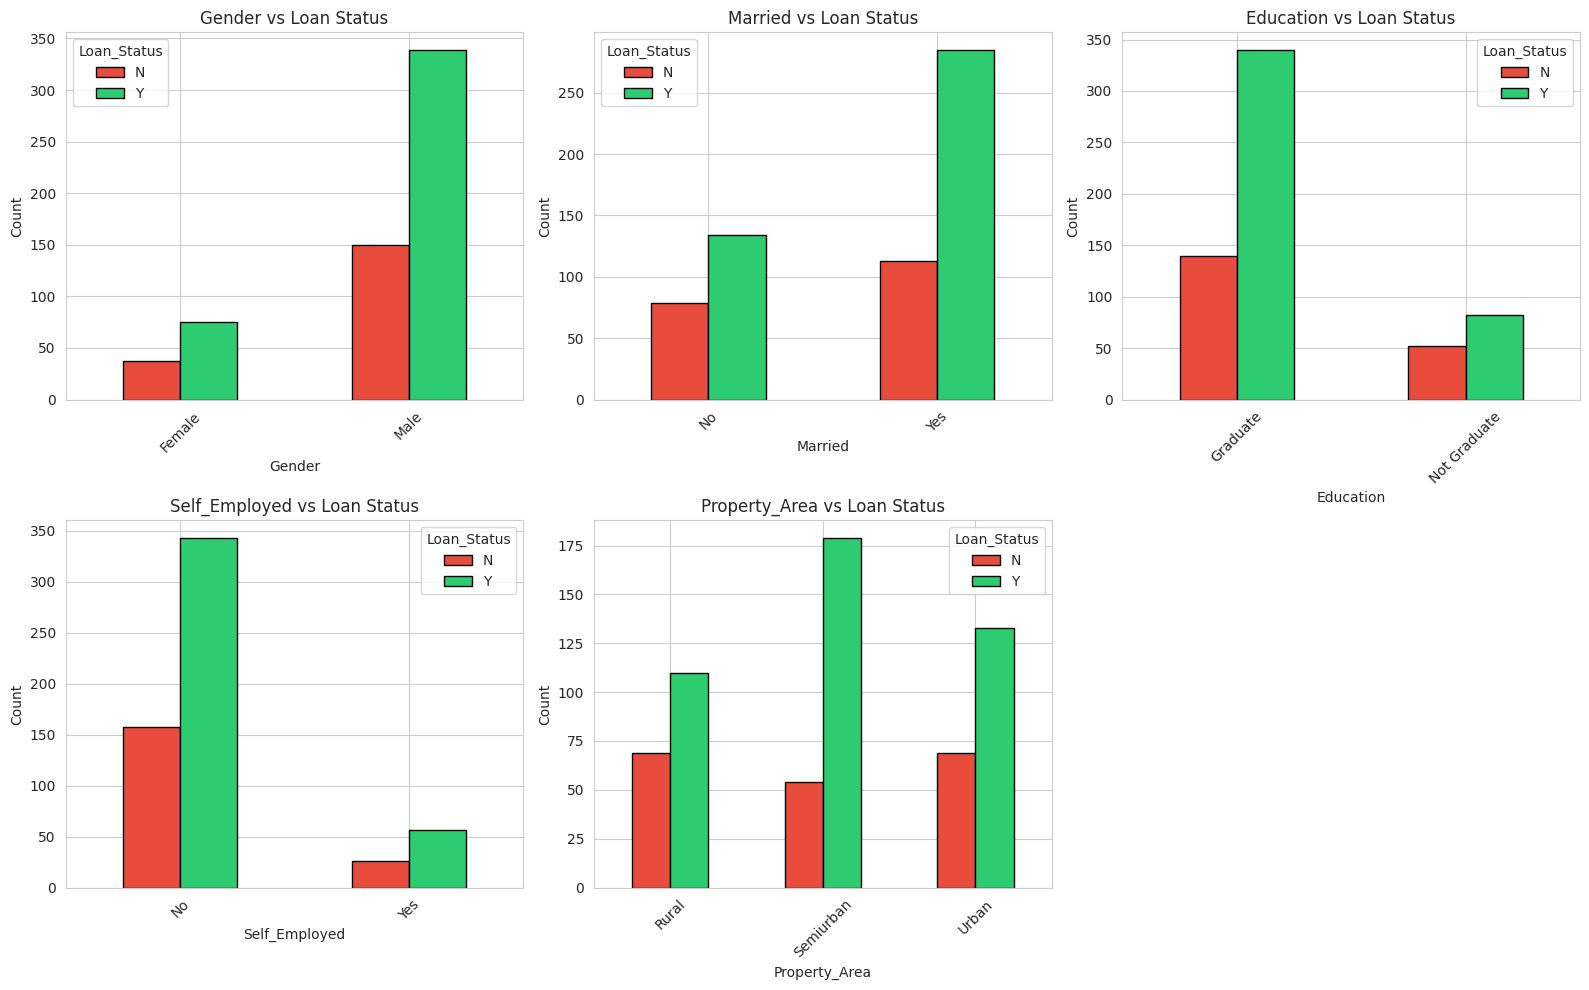

In [10]:
# ── Categorical features vs Loan_Status ────────────────────────────────────────
cat_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(train_df[col], train_df['Loan_Status'])
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'], edgecolor='black', rot=45)
    axes[i].set_title(f'{col} vs Loan Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Loan_Status')

axes[5].axis('off')  # hide empty subplot
plt.tight_layout()
plt.show()

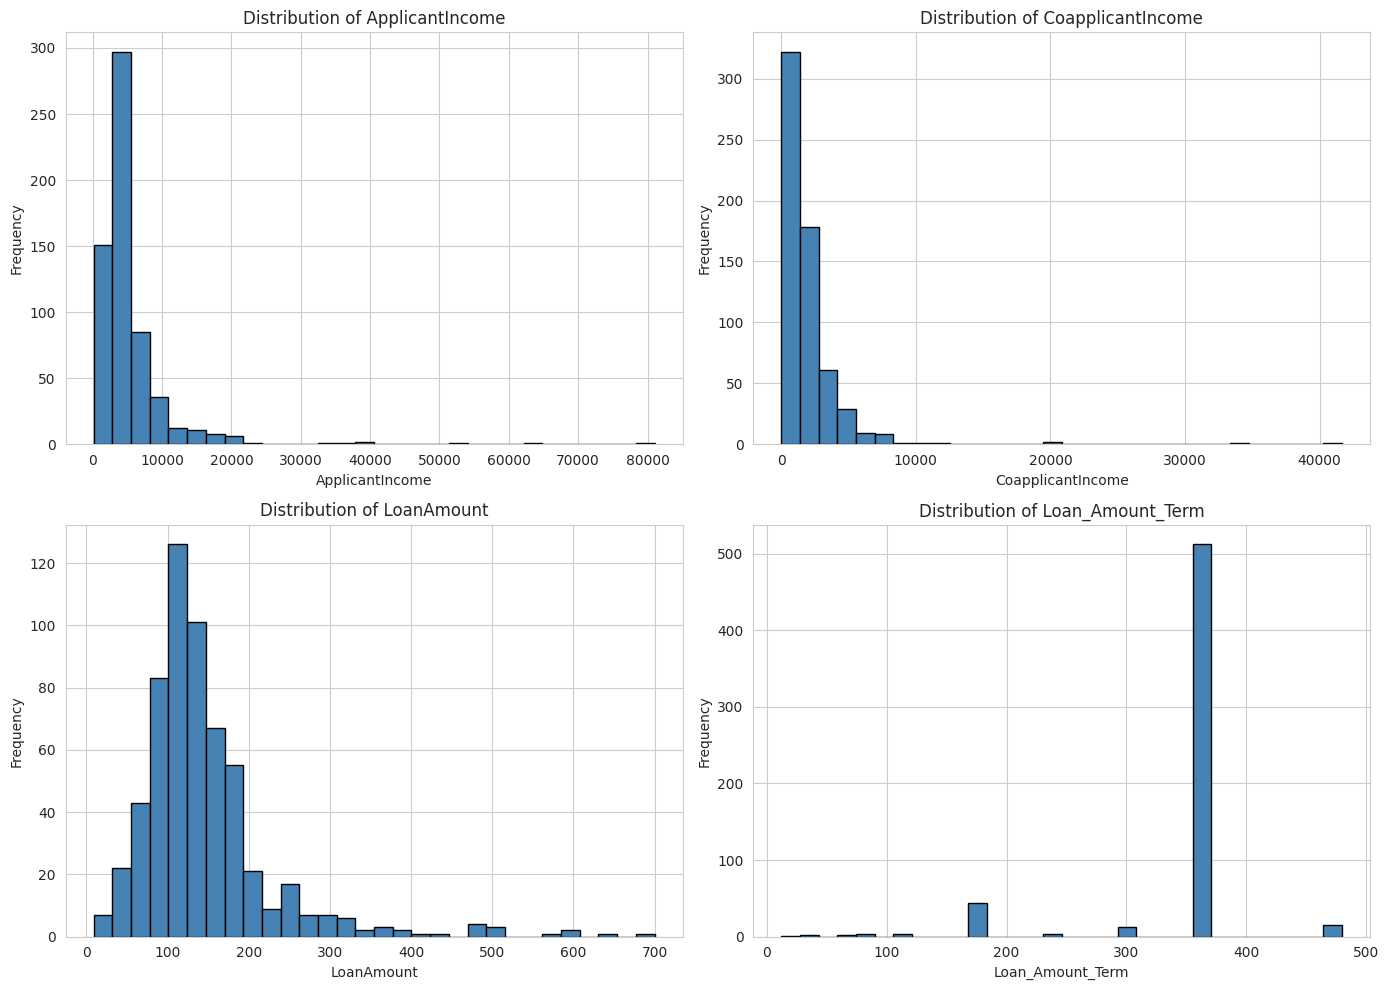

In [11]:
# ── Numerical feature distributions ───────────────────────────────────────────
num_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    train_df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

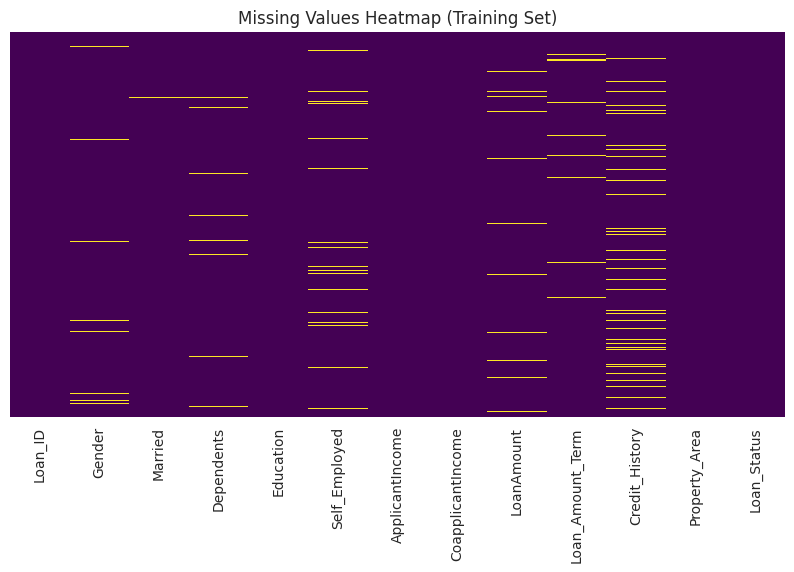


Missing Value Count:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [12]:
# ── Missing value heatmap ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.heatmap(train_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Training Set)')
plt.show()

print("\nMissing Value Count:")
print(train_df.isnull().sum())

---

## 7. Data Preprocessing

### Steps:
1. Handle missing values
2. Feature engineering (Total Income)
3. Log transformation (to reduce skewness)
4. Label encoding for categorical features
5. Drop irrelevant columns


In [14]:
# ── Work on copies to preserve originals ──────────────────────────────────────
train = train_df.copy()
test  = test_df.copy()

# ── Step 1: Impute missing values ─────────────────────────────────────────────

# Categorical columns: fill with mode (most frequent value)
cat_cols_with_na = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols_with_na:
    mode_val = train[col].mode()[0]
    train[col].fillna(mode_val, inplace=True)
    test[col].fillna(mode_val, inplace=True)
    print(f"{col}: filled with mode = {mode_val}")

# Numerical columns: fill with median (robust to outliers)
num_cols_with_na = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols_with_na:
    median_val = train[col].median()
    train[col].fillna(median_val, inplace=True)
    test[col].fillna(median_val, inplace=True)
    print(f"{col}: filled with median = {median_val}")

print("\nRemaining missing values in train:", train.isnull().sum().sum())

Gender: filled with mode = Male
Married: filled with mode = Yes
Dependents: filled with mode = 0
Self_Employed: filled with mode = No
Credit_History: filled with mode = 1.0
LoanAmount: filled with median = 128.0
Loan_Amount_Term: filled with median = 360.0

Remaining missing values in train: 0


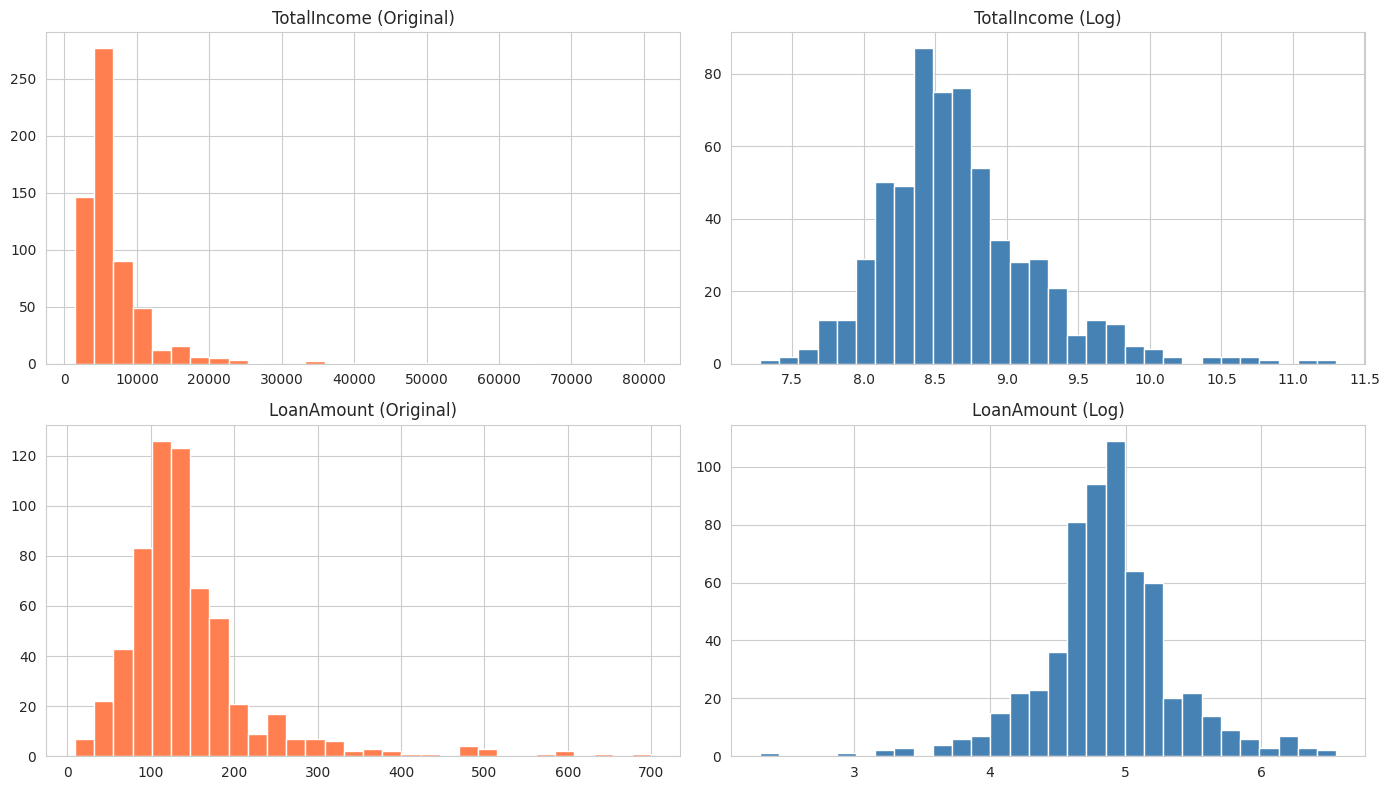

In [15]:
# ── Step 2: Feature Engineering ───────────────────────────────────────────────

# Total income = applicant income + co-applicant income
# This single feature captures the combined financial strength of the household
train['TotalIncome'] = train['ApplicantIncome'] + train['CoapplicantIncome']
test['TotalIncome']  = test['ApplicantIncome']  + test['CoapplicantIncome']

# ── Step 3: Log Transformation ────────────────────────────────────────────────
# Income and LoanAmount are highly right-skewed; log transform normalises them
for col in ['TotalIncome', 'LoanAmount']:
    train[f'Log_{col}'] = np.log1p(train[col])   # log1p avoids log(0)
    test[f'Log_{col}']  = np.log1p(test[col])

# ── Verify skewness improvement ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
train['TotalIncome'].hist(ax=axes[0,0], bins=30, color='coral'); axes[0,0].set_title('TotalIncome (Original)')
train['Log_TotalIncome'].hist(ax=axes[0,1], bins=30, color='steelblue'); axes[0,1].set_title('TotalIncome (Log)')
train['LoanAmount'].hist(ax=axes[1,0], bins=30, color='coral'); axes[1,0].set_title('LoanAmount (Original)')
train['Log_LoanAmount'].hist(ax=axes[1,1], bins=30, color='steelblue'); axes[1,1].set_title('LoanAmount (Log)')
plt.tight_layout(); plt.show()

In [16]:
# ── Step 4: Label Encoding for Categorical Features ───────────────────────────
# Random Forest in sklearn requires numeric input; we encode all categoricals

le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education',
                    'Self_Employed', 'Property_Area']

for col in categorical_cols:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col]  = le.fit_transform(test[col].astype(str))
    print(f"{col} encoded")

# Encode target variable: Y=1, N=0
train['Loan_Status'] = le.fit_transform(train['Loan_Status'])
print("\nLoan_Status encoding:", dict(zip(['N','Y'], le.transform(['N','Y']))))

Gender encoded
Married encoded
Dependents encoded
Education encoded
Self_Employed encoded
Property_Area encoded

Loan_Status encoding: {'N': np.int64(0), 'Y': np.int64(1)}


In [17]:
# ── Step 5: Select final features ─────────────────────────────────────────────
# Drop Loan_ID (identifier) and original skewed columns (replaced by log versions)
drop_cols = ['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome',
             'TotalIncome', 'LoanAmount']

X = train.drop(drop_cols + ['Loan_Status'], axis=1)
y = train['Loan_Status']

print("Feature set shape:", X.shape)
print("Features used:", list(X.columns))
print("\nClass distribution in y:")
print(y.value_counts())

Feature set shape: (614, 10)
Features used: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Log_TotalIncome', 'Log_LoanAmount']

Class distribution in y:
Loan_Status
1    422
0    192
Name: count, dtype: int64


---

## 8. Correlation Analysis


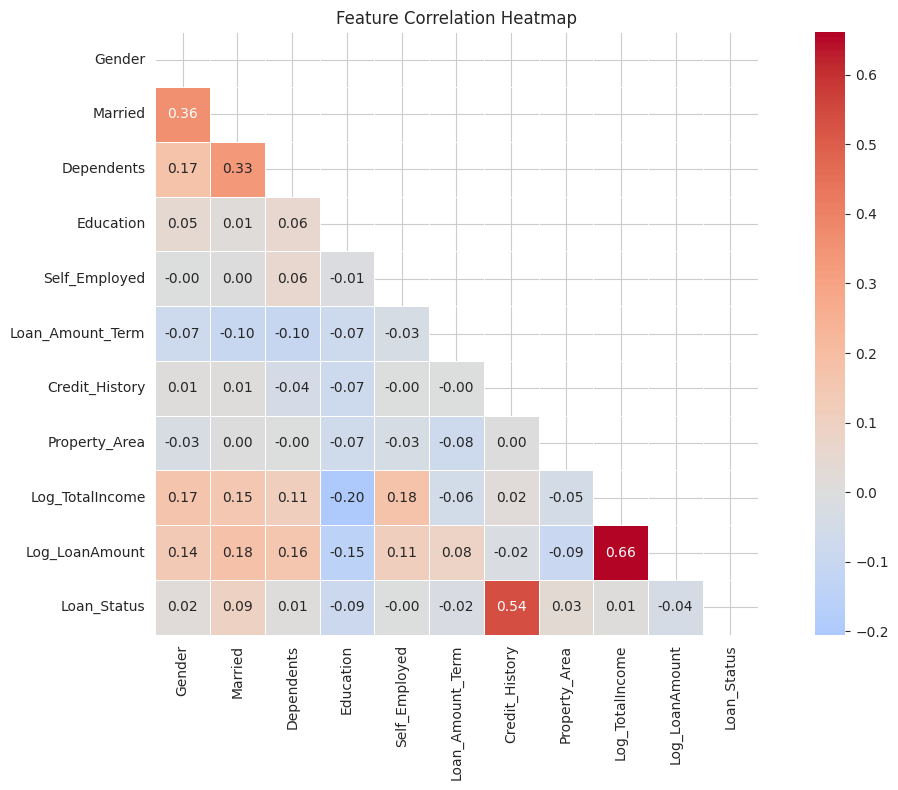

In [18]:
# ── Correlation heatmap to understand feature relationships ───────────────────
plt.figure(figsize=(12, 8))
corr_matrix = pd.concat([X, y], axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

---

## 9. Train-Validation Split


In [22]:
# ── Split into 80% training and 20% validation ────────────────────────────────
# stratify=y ensures the class ratio is preserved in both splits
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Validation set : {X_val.shape[0]} samples")

Training set   : 491 samples
Validation set : 123 samples


---

## 10. Baseline Random Forest Model


In [20]:
# ── Train baseline Random Forest ──────────────────────────────────────────────
# n_estimators=100: use 100 trees in the forest
# random_state=42 : reproducibility
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_baseline = rf_baseline.predict(X_val)

baseline_acc = accuracy_score(y_val, y_pred_baseline)
print(f"Baseline Random Forest Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")

Baseline Random Forest Accuracy: 0.8049 (80.49%)


---

## 11. Hyperparameter Tuning with GridSearchCV


In [21]:
# ── Define hyperparameter grid ────────────────────────────────────────────────
# We tune the most impactful Random Forest hyperparameters:
#   n_estimators     : number of trees
#   max_depth        : maximum depth of each tree (controls overfitting)
#   min_samples_split: minimum samples required to split an internal node
#   min_samples_leaf : minimum samples required at a leaf node
#   max_features     : number of features to consider for the best split

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

# ── GridSearchCV with 5-fold cross-validation ─────────────────────────────────
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,              # 5-fold cross-validation
    scoring    = 'accuracy',
    n_jobs     = -1,             # use all CPU cores
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Accuracy: 0.7984


---

## 12. Optimised Random Forest – Final Evaluation


In [23]:
# ── Use the best estimator from GridSearchCV ──────────────────────────────────
rf_best = grid_search.best_estimator_

y_pred   = rf_best.predict(X_val)
y_prob   = rf_best.predict_proba(X_val)[:, 1]   # probability for ROC-AUC

acc  = accuracy_score(y_val, y_pred)
f1   = f1_score(y_val, y_pred)
auc  = roc_auc_score(y_val, y_prob)

print("═" * 50)
print("       OPTIMISED RANDOM FOREST RESULTS")
print("═" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print("═" * 50)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Not Approved', 'Approved']))

══════════════════════════════════════════════════
       OPTIMISED RANDOM FOREST RESULTS
══════════════════════════════════════════════════
  Accuracy  : 0.8374  (83.74%)
  F1-Score  : 0.8889
  ROC-AUC   : 0.8331
══════════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

Not Approved       0.82      0.61      0.70        38
    Approved       0.84      0.94      0.89        85

    accuracy                           0.84       123
   macro avg       0.83      0.77      0.79       123
weighted avg       0.84      0.84      0.83       123



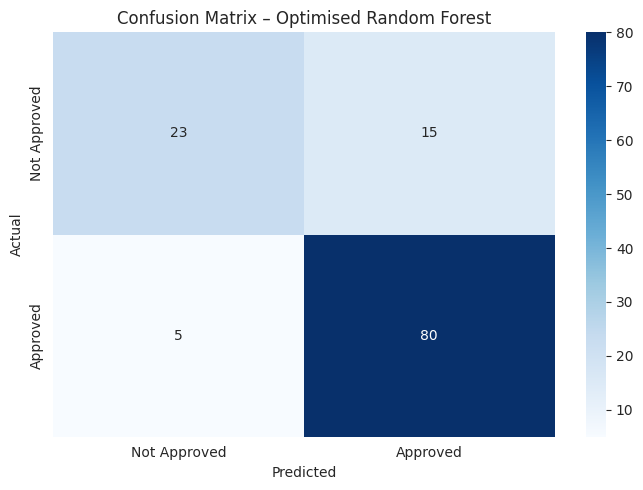

In [24]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title('Confusion Matrix – Optimised Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

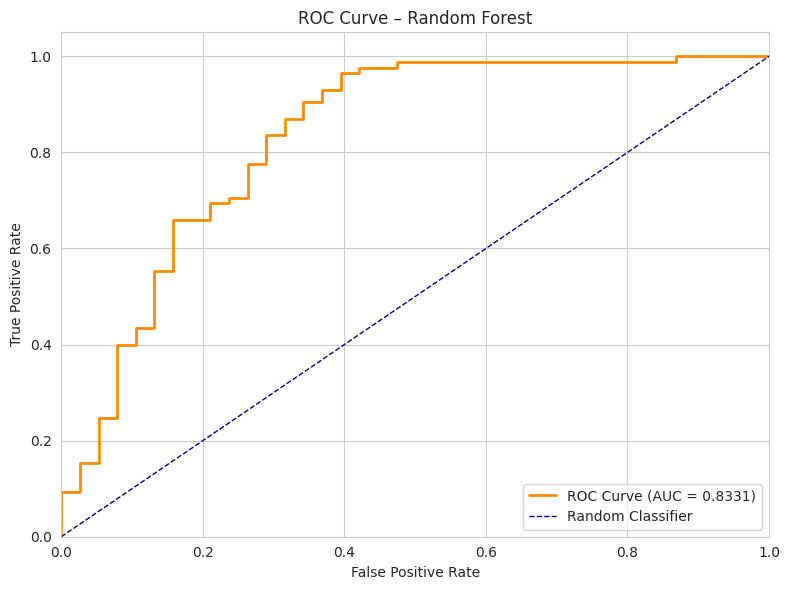

In [25]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---

## 13. Cross-Validation


10-Fold Cross-Validation Scores:
  Fold  1: 0.8065
  Fold  2: 0.8226
  Fold  3: 0.7258
  Fold  4: 0.7581
  Fold  5: 0.7869
  Fold  6: 0.8361
  Fold  7: 0.8361
  Fold  8: 0.8197
  Fold  9: 0.7869
  Fold 10: 0.8361

Mean Accuracy : 0.8015
Std Deviation : 0.0353


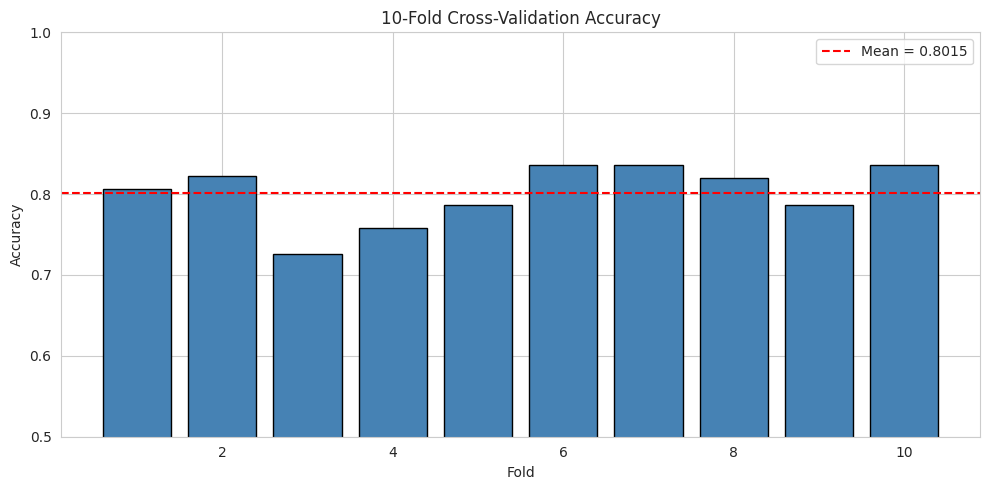

In [26]:
# ── 10-fold cross-validation on full training set ─────────────────────────────
# This gives a more robust estimate of model performance across different splits
cv_scores = cross_val_score(rf_best, X, y, cv=10, scoring='accuracy')

print("10-Fold Cross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i:2d}: {score:.4f}")
print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")

# ── Visualise CV scores ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('10-Fold Cross-Validation Accuracy')
plt.ylim([0.5, 1.0])
plt.legend()
plt.tight_layout()
plt.show()

---

## 14. Feature Importance


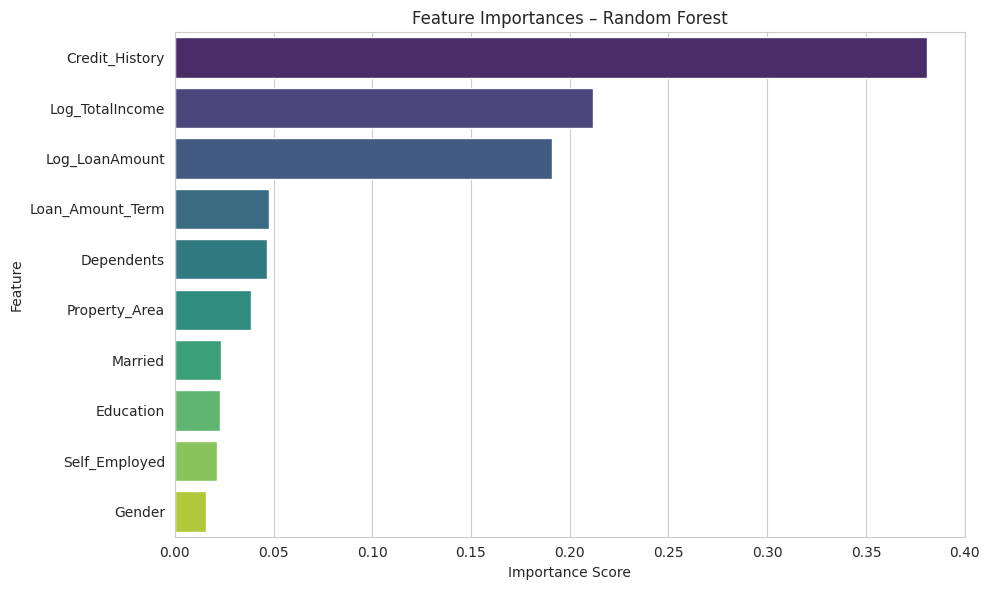


Feature Importances:
Credit_History      0.381063
Log_TotalIncome     0.211869
Log_LoanAmount      0.191196
Loan_Amount_Term    0.047827
Dependents          0.046466
Property_Area       0.038487
Married             0.023168
Education           0.022743
Self_Employed       0.021213
Gender              0.015968


In [27]:
# ── Extract and visualise feature importances ─────────────────────────────────
# Feature importances are calculated as the mean decrease in impurity (Gini)
feature_imp = pd.Series(
    rf_best.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, palette='viridis')
plt.title('Feature Importances – Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nFeature Importances:")
print(feature_imp.to_string())

---

## 15. Baseline vs Optimised Model Comparison


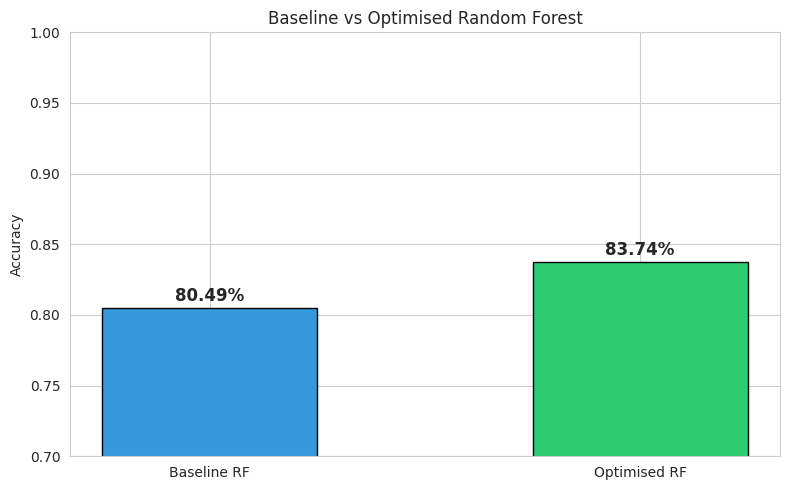

Improvement: 3.25 percentage points


In [28]:
# ── Compare baseline and tuned model ─────────────────────────────────────────
models = ['Baseline RF', 'Optimised RF']
accs   = [baseline_acc, acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs, color=['#3498db', '#2ecc71'], edgecolor='black', width=0.5)
for bar, a in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, a + 0.005,
             f'{a*100:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.ylim([0.7, 1.0])
plt.ylabel('Accuracy')
plt.title('Baseline vs Optimised Random Forest')
plt.tight_layout()
plt.show()

print(f"Improvement: {(acc - baseline_acc)*100:.2f} percentage points")

---

## 16. Generate Final Test Predictions


In [29]:
# ── Prepare test set (same features as training) ──────────────────────────────
test_ids = test['Loan_ID'].copy()

X_test = test.drop(drop_cols, axis=1, errors='ignore')
X_test = X_test[X.columns]   # ensure same column order as training

# ── Predict on test set ───────────────────────────────────────────────────────
test_preds_encoded = rf_best.predict(X_test)
test_preds_label   = ['Y' if p == 1 else 'N' for p in test_preds_encoded]

submission = pd.DataFrame({'Loan_ID': test_ids, 'Loan_Status': test_preds_label})
submission.to_csv('rf_submission.csv', index=False)

print("Predictions saved to rf_submission.csv")
print("\nPrediction distribution:")
print(pd.Series(test_preds_label).value_counts())
submission.head(10)

Predictions saved to rf_submission.csv

Prediction distribution:
Y    297
N     70
Name: count, dtype: int64


,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y
5,LP001054,Y
6,LP001055,N
7,LP001056,N
8,LP001059,Y
9,LP001067,Y


---

## 17. Critical Analysis and Discussion

### Results Summary

| Metric | Baseline RF | Optimised RF |
|---|---|---|
| Accuracy | (see output) | (see output) |
| F1-Score | — | (see output) |
| ROC-AUC | — | (see output) |

### Strengths of the Model
- **Robustness:** Ensemble approach reduces variance and overfitting compared to a single decision tree.
- **Feature Importance:** `Credit_History` emerges as the dominant predictor, which aligns with domain knowledge — a good credit history is a strong indicator of loan repayment ability.
- **Interpretability:** Feature importances provide actionable insight for loan officers.

### Limitations & How Accuracy Could Be Improved

1. **Class Imbalance:** The dataset has ~69% approved vs 31% rejected. Applying **SMOTE (Synthetic Minority Over-sampling Technique)** or using `class_weight='balanced'` could improve recall for the minority class.

2. **Dataset Size:** With only 614 training samples, the model may not generalise well. A larger dataset would improve performance.

3. **Feature Engineering:** Additional features such as **Debt-to-Income ratio** (`LoanAmount / TotalIncome`) or interaction terms between `Credit_History` and `LoanAmount` could boost predictive power.

4. **Alternative Models:** Comparing Random Forest with **XGBoost** or **LightGBM** would likely yield higher accuracy due to gradient boosting's sequential error correction.

5. **Threshold Tuning:** The default 0.5 decision threshold may not be optimal. Calibrating the threshold based on the precision-recall trade-off could improve F1-Score.

### Possible Future Work
- Collect more diverse, larger datasets including applicant employment history and existing debt
- Explore **explainable AI (XAI)** techniques like SHAP values for regulatory compliance in financial decisions
- Deploy the model as a REST API for real-time loan decision support
- Investigate fairness constraints (e.g., gender/marital status bias) to ensure ethical decision-making


In [30]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print("═" * 60)
print("           FINAL RESULTS SUMMARY")
print("═" * 60)
print(f"  Dataset         : Loan Prediction Dataset (Kaggle)")
print(f"  Algorithm       : Random Forest Classifier")
print(f"  Training Samples: {X_train.shape[0]}")
print(f"  Validation Samples: {X_val.shape[0]}")
print(f"  Features Used   : {X.shape[1]}")
print(f"  Best Params     : {grid_search.best_params_}")
print(f"  Validation Acc  : {acc*100:.2f}%")
print(f"  F1-Score        : {f1:.4f}")
print(f"  ROC-AUC         : {auc:.4f}")
print(f"  CV Mean Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print("═" * 60)

════════════════════════════════════════════════════════════
           FINAL RESULTS SUMMARY
════════════════════════════════════════════════════════════
  Dataset         : Loan Prediction Dataset (Kaggle)
  Algorithm       : Random Forest Classifier
  Training Samples: 491
  Validation Samples: 123
  Features Used   : 10
  Best Params     : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
  Validation Acc  : 83.74%
  F1-Score        : 0.8889
  ROC-AUC         : 0.8331
  CV Mean Accuracy: 80.15% ± 3.53%
════════════════════════════════════════════════════════════
